#Kmeans Clustering


Dataset: Mall Customers.csv

Link to download: [Mall Customers dataset](https://www.kaggle.com/code/heeraldedhia/kmeans-clustering-for-customer-data/input)

About the dataset:

This input file contains the basic information (ID, age, gender, income, spending score) about the customers of a mall. Spending Score is something you assign to the customer based on your defined parameters like customer behavior and purchasing data.

#1. Importing the required libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


#2. Load the dataset and choose the right features

In [ ]:

# 2) Load dataset
df = pd.read_csv("/content/Mall_Customers.csv")
print("First 5 rows of dataset:")
print(df.head())

# 3) Select two meaningful numeric features for visualization
# (Change these column names based on your dataset!)
features = ["Annual Income (k$)", "Spending Score (1-100)"]
X = df[features]

# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)



First 5 rows of dataset:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


#3. Elbow method - To find the optimal k-cluster value

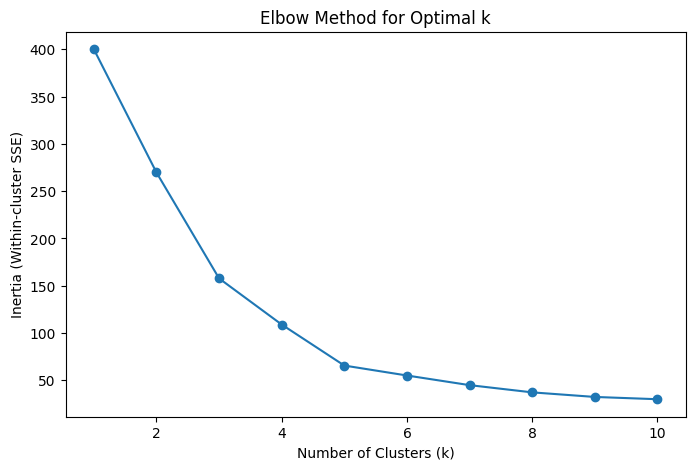

In [ ]:
# 4) Elbow Method
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-cluster SSE)")
plt.title("Elbow Method for Optimal k")
plt.show()


#4. Train the model

Step 1: Initialization
KMeans randomly picks k centroids.

Step 2: Assignment
Each point is assigned to the nearest centroid → forming clusters.

Step 3: Update
Centroids are recalculated as the mean of assigned points.

Step 4: Repeat
Assignment & update continue until centroids stabilize (no significant change).

In [ ]:
# 6) Final KMeans (choose k, say 5)
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(scaled_data)


#5. Visualizing the results

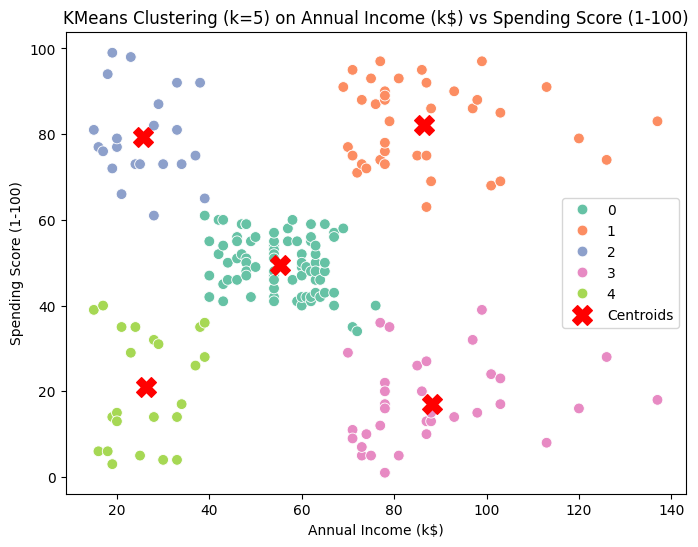

In [ ]:
# Inverse transform centroids (to plot in original scale)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

# 7) Visualization with chosen 2 features
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x=features[0], y=features[1], hue="Cluster", palette="Set2", s=60)
plt.scatter(centroids[:,0], centroids[:,1],
            c="red", marker="X", s=200, label="Centroids")
plt.legend()
plt.title(f"KMeans Clustering (k={optimal_k}) on {features[0]} vs {features[1]}")
plt.show()

#Manual Predictions


Manual Predictions:
Customer [60, 40] -> Cluster 0
Customer [20, 90] -> Cluster 2
Customer [100, 20] -> Cluster 3


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

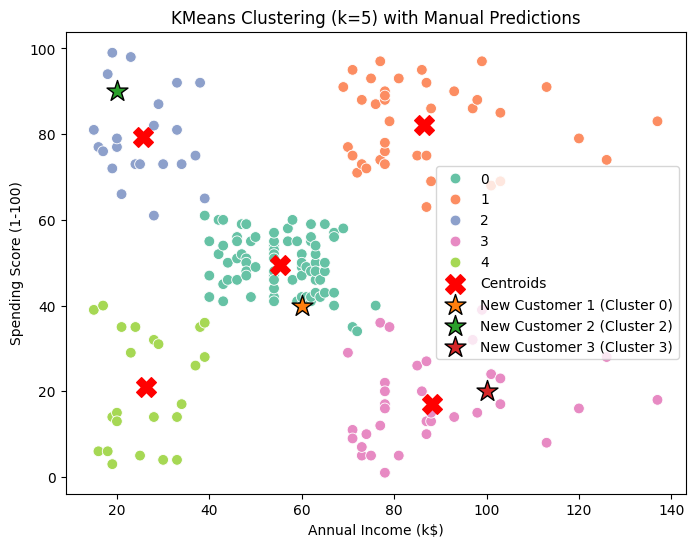

In [ ]:
# ---- Manual Prediction Function ----
def predict_cluster(new_point, model, scaler):
    """
    new_point: [Annual Income, Spending Score]
    """
    scaled_point = scaler.transform([new_point])
    cluster = model.predict(scaled_point)[0]
    return cluster

# Example manual predictions
new_customers = [
    [60, 40],   # income=60k, spending score=40
    [20, 90],   # income=20k, spending score=90
    [100, 20],  # income=100k, spending score=20
]

print("\nManual Predictions:")
for customer in new_customers:
    cluster = predict_cluster(customer, kmeans, scaler)
    print(f"Customer {customer} -> Cluster {cluster}")

# 7) Visualization with chosen 2 features + new customers
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x=features[0], y=features[1], hue="Cluster", palette="Set2", s=60)
plt.scatter(centroids[:,0], centroids[:,1],
            c="red", marker="X", s=200, label="Centroids")

# Plot new customers with star marker
for i, customer in enumerate(new_customers):
    cluster = predict_cluster(customer, kmeans, scaler)
    plt.scatter(customer[0], customer[1],
                marker="*", s=250, edgecolor="black",
                label=f"New Customer {i+1} (Cluster {cluster})")

plt.legend()
plt.title(f"KMeans Clustering (k={optimal_k}) with Manual Predictions")
plt.xlabel(features[0])
plt.ylabel(features[1])
plt.show()
